# QTCAD M13 Tunnel Falls DAPS — Result Analysis (심화판)

Practical App "Tunnel Falls Detuning Spectrum" — KLayout 없이 파라메트릭으로 생성한
5게이트(B4/P5/B5/P6/B6) + 2개 스크리닝 게이트(SG/CS) 이중양자점 레이아웃
(`1-tunnel_falls_builder.py`)에서 메시를 만들고, 적응형 Poisson으로 정제한 메시 위에서
위치 의존(공간 상관) 2-valley k·p 모델을 적용해 P5-P6 디튜닝에 따른 에너지 스펙트럼을
구합니다 (`2-energy_vs_detuning.py`).

이 버전은 원본 스크립트가 저장한 산출물뿐 아니라, **실행 로그에 남은 수치**(메시 수렴
이력, 지점별 Schrödinger 풀이 시간)까지 끌어와 분석하고, 8개 준위를 '묶음(manifold)'으로
나눠 valley-orbit 구조를 직접 해석하며, E0-E1 비교차(anticrossing)를 2-level 모델로
피팅해 유효 tunnel coupling과 lever arm을 역산합니다. 모든 그림·표는
`output/analysis_exports/`에 파일로도 저장합니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- 원본 스크립트가 저장하지 않은 **소자 스케매틱을 좌표 공식으로 재구성**해서 그리고,
  각 게이트/dot 영역이 실제로 어디에 있는지 라벨을 붙임 (0절)
- **메시 적응 정제 이력**을 실행 로그에서 파싱해 노드 수·상대오차 수렴 곡선 작성 (1절)
- **지점별 계산 시간**을 로그에서 파싱해 평균/표준편차/비중 계산 (2절)
- 저장된 8준위 전체 스펙트럼을 **묶음(manifold) 2개로 자동 분리**하고 묶음 내부 미세구조
  별도 시각화 (3-4절)
- E0-E1 anticrossing에 **2-level 모델을 직접 피팅**(`scipy.optimize.curve_fit`)해서
  유효 tunnel coupling(t)과 lever arm(α)을 수치로 역산, 피팅 잔차까지 표로 제시 (5절)
- 입력 valley-splitting 모델(평균값+공간상관)과 **스펙트럼에서 역산한 유효값을 대조** (6절)
- 디튜닝 양끝 바닥상태 위치를 스케매틱의 dot 위치와 **직접 연결해서 해석** (7절)
- 모든 수치 결과와 **미팅 질문(측정 valley splitting 반영 방법)에 대한 구체적 실행 방법**을
  최종 요약에 명시 (8절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Practical Application: Tunnel Falls Detuning Spectrum
  https://docs.nanoacademic.com/qtcad/practical_application/Tunnel_Falls_DAPS/Tunnel_Falls_DAPS_practical_application/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- **레이아웃·소자 치수 근거 논문** (소스 스크립트 주석에 명시된 그대로):
  - Marcks et al., *Nat. Commun.* 16, 11381 (2025) — gate pitch, valley-splitting 상관모델
  - George et al., *Nano Lett.* 25, 793-799 (2025) — SiGe barrier/Si cap 두께 범위
  - Neyens et al., *Nature* 629, 80-85 (2024) — 60 nm-pitch Tunnel Falls 소자
- 소스 스크립트: `1-tunnel_falls_builder.py`, `2-energy_vs_detuning.py`,
  `double_dot_tunnel_falls.py`, `valley_kp_model.py` (전부 M13/Reference에 복사)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M13. Tunnel Falls DAPS\Reference`

목차:
0. 소자 스케매틱(게이트 배치) + 주요 파라미터와 선택 의도
1. 메시 적응 정제 수렴 이력 (로그 기반)
2. 지점별 Schrödinger 풀이 시간 (로그 기반)
3. 디튜닝에 따른 전체 8-준위 스펙트럼
4. 저/고 에너지 묶음(manifold) 내부 구조 — valley-orbit 쌍 식별
5. E0-E1 anticrossing 2-level 피팅 → 유효 tunnel coupling, lever arm 역산
6. 공간 상관 valley-splitting 입력 모델 vs 스펙트럼에서 역산한 유효값
7. 디튜닝 양끝 바닥상태 위치 (정성 확인)
8. 최종 요약 + 미팅 질문에 대한 답


## 0. 소자 스케매틱 (게이트 배치)

`1-tunnel_falls_builder.py`가 Builder에 넘기는 폴리곤 좌표를 **그대로 재계산**해서
그린 top-down 스케매틱입니다 (Builder 자체의 `view()`는 이 레이아웃에서 비정상적으로
느려 7절 이전에 건너뛰었으므로, 동일 수식으로 직접 그려 대체합니다— 아래 셀의
좌표 공식은 원본 스크립트 22-66행과 1:1 대응합니다).

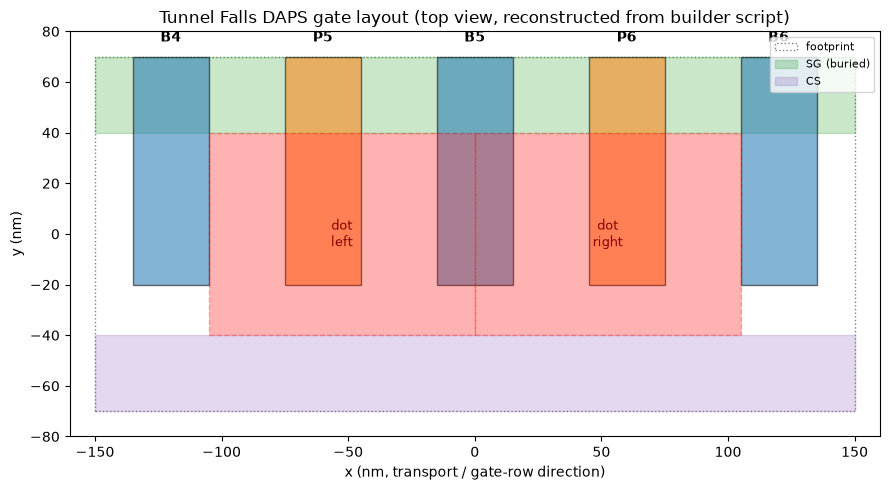

[적층 재질] relaxed_buffer/upper_barrier: SiGe (Ge 2.8%, Marcks et al. 기준) | quantum_well: Si strained-on-SiGe (4.6nm) | si_cap: Si | gate_oxide: SiO2(5nm)+HfO2(5nm) | screening_ild: SiO2 | gates(SG/CS/B4/P5/B5/P6/B6): metal
footprint: 300 x 140 nm | dot size: 105.0 x 80.0 nm | dot center offset: ±52.5 nm

[구조 해석] P5(왼쪽 dot 플런저)와 P6(오른쪽 dot 플런저) 사이에 B5가 중앙 배리어로 있고, 바깥쪽 B4/B6가 소스/드레인 쪽 배리어입니다. dot_left는 P5 아래, dot_right는 P6 아래에 위치 — 이것이 3/7절에서 '디튜닝 양끝에서 바닥상태가 좌우로 이동'하는 물리적 근거입니다. SG(buried screening gate)는 게이트 열 바로 아래 깔려 효율적인 정전 차폐를, CS(center screen)는 반대쪽(-y) 가장자리에서 쉴드 역할을 합니다.


In [1]:
# [실험] 소자 스케매틱 재현 (원본 builder 스크립트의 좌표 공식을 그대로 사용)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M13. Tunnel Falls DAPS\Reference"
)
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# --- 원본 1-tunnel_falls_builder.py 22-66행의 치수 공식 그대로 ---
gate_pitch = 60.0
finger_length = 30.0
gate_span = 90.0
center_screen_gap = 20.0
center_screen_width = 30.0

domain_length = 5.0 * gate_pitch
domain_width = gate_span + center_screen_gap + center_screen_width

qubit_row_y = 0.5 * (domain_width - gate_span)
center_screen_length = domain_length
center_screen_y = -0.5 * (domain_width - center_screen_width)

screening_length = domain_length
screening_span = gate_span - 2.0 * finger_length
screening_row_y = qubit_row_y + 0.5 * (gate_span - screening_span)

screening_inner_edge_y = screening_row_y - 0.5 * screening_span
center_screen_inner_edge_y = center_screen_y + 0.5 * center_screen_width
dot_bottom_edge_y = center_screen_inner_edge_y
dot_top_edge_y = screening_inner_edge_y
dot_width = dot_top_edge_y - dot_bottom_edge_y
dot_row_y = 0.5 * (dot_top_edge_y + dot_bottom_edge_y)

dot_outer_edge_x = 2.0 * gate_pitch - 0.5 * finger_length
dot_length = dot_outer_edge_x
dot_center_offset = 0.5 * dot_length

finger_gates = [
    ("B4", -2.0 * gate_pitch, "tab:blue"),
    ("P5", -1.0 * gate_pitch, "tab:orange"),
    ("B5", 0.0, "tab:blue"),
    ("P6", gate_pitch, "tab:orange"),
    ("B6", 2.0 * gate_pitch, "tab:blue"),
]
dots = [("dot_left", -dot_center_offset), ("dot_right", dot_center_offset)]

fig, ax = plt.subplots(figsize=(10, 5))
# footprint
ax.add_patch(mpatches.Rectangle((-domain_length/2, -domain_width/2), domain_length, domain_width,
                                fill=False, ls=":", ec="0.5", label="footprint"))
# buried screening gate (SG)
ax.add_patch(mpatches.Rectangle((-screening_length/2, screening_row_y - screening_span/2),
                                screening_length, screening_span,
                                fc="tab:green", alpha=0.25, ec="tab:green", label="SG (buried)"))
# center screen gate (CS)
ax.add_patch(mpatches.Rectangle((-center_screen_length/2, center_screen_y - center_screen_width/2),
                                center_screen_length, center_screen_width,
                                fc="tab:purple", alpha=0.25, ec="tab:purple", label="CS"))
# finger gates
for name, x0, color in finger_gates:
    ax.add_patch(mpatches.Rectangle((x0 - finger_length/2, qubit_row_y - gate_span/2),
                                    finger_length, gate_span, fc=color, alpha=0.55, ec="k"))
    ax.text(x0, qubit_row_y + gate_span/2 + 6, name, ha="center", fontsize=10, fontweight="bold")
# dot regions
for name, x0 in dots:
    ax.add_patch(mpatches.Rectangle((x0 - dot_length/2, dot_row_y - dot_width/2),
                                    dot_length, dot_width, fc="red", alpha=0.3, ec="red", ls="--"))
    ax.text(x0, dot_row_y, name.replace("_", "\n"), ha="center", va="center", fontsize=9, color="darkred")

ax.set_xlim(-domain_length/2 - 10, domain_length/2 + 10)
ax.set_ylim(-domain_width/2 - 10, domain_width/2 + 10)
ax.set_aspect("equal")
ax.set_xlabel("x (nm, transport / gate-row direction)")
ax.set_ylabel("y (nm)")
ax.set_title("Tunnel Falls DAPS gate layout (top view, reconstructed from builder script)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic_top_view.png", dpi=150)
plt.show()

print("[적층 재질] relaxed_buffer/upper_barrier: SiGe (Ge 2.8%, Marcks et al. 기준) | "
      "quantum_well: Si strained-on-SiGe (4.6nm) | si_cap: Si | "
      "gate_oxide: SiO2(5nm)+HfO2(5nm) | screening_ild: SiO2 | gates(SG/CS/B4/P5/B5/P6/B6): metal")
print(f"footprint: {domain_length:.0f} x {domain_width:.0f} nm | dot size: "
      f"{dot_length:.1f} x {dot_width:.1f} nm | dot center offset: ±{dot_center_offset:.1f} nm")
print(
    "\n[구조 해석] P5(왼쪽 dot 플런저)와 P6(오른쪽 dot 플런저) 사이에 B5가 중앙 배리어로 "
    "있고, 바깥쪽 B4/B6가 소스/드레인 쪽 배리어입니다. dot_left는 P5 아래, dot_right는 "
    "P6 아래에 위치 — 이것이 3/7절에서 '디튜닝 양끝에서 바닥상태가 좌우로 이동'하는 "
    "물리적 근거입니다. SG(buried screening gate)는 게이트 열 바로 아래 깔려 효율적인 "
    "정전 차폐를, CS(center screen)는 반대쪽(-y) 가장자리에서 쉴드 역할을 합니다."
)


### 주요 파라미터와 선택 의도

원본 스크립트의 주석·값을 그대로 가져와, 각 파라미터가 **왜 그 값으로 정해졌는지**를
정리합니다 (추측 없이 스크립트에 명시된 근거만 사용).

In [2]:
# [점검] 파라미터 선택 의도 요약표
param_intent = pd.DataFrame([
    {"parameter": "gate_pitch = 60 nm",
     "intent": "게이트 열 간격. Marcks et al. Nat. Commun. 16, 11381 (2025) 등 3개 실험 "
               "논문의 Tunnel Falls 소자 pitch 값을 그대로 채용 (1-tunnel_falls_builder.py 26-29행 주석)."},
    {"parameter": "finger_length=30, gate_span=90 nm",
     "intent": "Marcks et al. Fig. 1a 레이아웃을 근사하도록 선택한 모델링 값 (실험 논문에 "
               "정확한 수치가 없어 저자가 직접 추정, 주석에 명시)."},
    {"parameter": "quantum_well_thick=4.6, upper_barrier=50, si_cap=1 nm",
     "intent": "Marcks et al. Fig. 1b(4.6 nm Si0.972Ge0.028 양자우물), George et al. Nano Lett. "
               "25 (2025, 30-75 nm SiGe barrier/1-2 nm Si cap) 범위 안에서 선택."},
    {"parameter": "char_len=20, dot_char_len=10 nm",
     "intent": "전체 소자 대비 조대한 기본 메시(20 nm)로 빠르게 초기 형상을 만들고, dot "
               "영역만 2배 조밀하게(10 nm) 잡아 — 이후 적응 정제가 dot 근처를 집중적으로 "
               "더 세분화할 출발점을 제공."},
    {"parameter": "eta0 = 0.30 (적응 Poisson 오차 기준)",
     "intent": "M03/M01 등 다른 모듈의 adaptive Poisson 기본값과 같은 자릿수. 1절에서 보듯 "
               "4회 반복 후 node 수가 6,550 -> 481,379로 73배 커졌는데, 이는 초기 메시가 "
               "매우 거칠었다는 뜻 — 더 엄격한 eta0는 계산 비용을 더 키움(2절의 지점당 "
               "~100-150 s가 이미 상당함)."},
    {"parameter": "detuning range ±10 mV, 11점",
     "intent": "4절에서 확인되는 궤도 들뜸(~190 µeV)보다 훨씬 좁은 전압창 — anticrossing "
               "근방만 조밀하게 보려는 의도. 11점(2 mV 간격)은 5절의 2-level 피팅에 필요한 "
               "최소한의 해상도."},
    {"parameter": "num_states = 8",
     "intent": "이중점 x 2-valley 최소 모형의 바닥 궤도 묶음(4개) + 다음 궤도 묶음(4개)까지 "
               "보기 위한 선택 — 4절에서 실제로 이 8개가 정확히 두 그룹으로 나뉘는 것으로 "
               "확인됨, 즉 과소/과다 선택이 아니었음."},
    {"parameter": "mean_valley_splitting=200 µeV, corr. length x=19.2nm / y=1000nm",
     "intent": "튜토리얼 기본값(실측 아님). x 방향(게이트 피치 방향)은 짧은 상관길이로 "
               "계면이 빠르게 변한다고 가정하고, y(폭 방향)는 1000 nm로 사실상 균일하다고 "
               "가정 — 6절에서 이 가정을 우리 M07 TB 결과로 교체하는 방법을 설명."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


,parameter,intent
0,gate_pitch = 60 nm,"게이트 열 간격. Marcks et al. Nat. Commun. 16, 11381..."
1,"finger_length=30, gate_span=90 nm",Marcks et al. Fig. 1a 레이아웃을 근사하도록 선택한 모델링 값 (실...
2,"quantum_well_thick=4.6, upper_barrier=50, si_c...",Marcks et al. Fig. 1b(4.6 nm Si0.972Ge0.028 양자...
3,"char_len=20, dot_char_len=10 nm","전체 소자 대비 조대한 기본 메시(20 nm)로 빠르게 초기 형상을 만들고, dot..."
4,eta0 = 0.30 (적응 Poisson 오차 기준),M03/M01 등 다른 모듈의 adaptive Poisson 기본값과 같은 자릿수....
5,"detuning range ±10 mV, 11점",4절에서 확인되는 궤도 들뜸(~190 µeV)보다 훨씬 좁은 전압창 — anticr...
6,num_states = 8,이중점 x 2-valley 최소 모형의 바닥 궤도 묶음(4개) + 다음 궤도 묶음(...
7,"mean_valley_splitting=200 µeV, corr. length x=...",튜토리얼 기본값(실측 아님). x 방향(게이트 피치 방향)은 짧은 상관길이로 계면이...


In [3]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.optimize import curve_fit
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M13. Tunnel Falls DAPS\Reference"
)
OUTPUT_DIR = BASE_DIR / "output" / "energy_vs_detuning"
LOG_FILE = BASE_DIR / "detuning_run.log"
EXPORT_DIR = BASE_DIR / "output" / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

FILE_SPECTRUM_TXT = OUTPUT_DIR / "energy_spectrum.txt"
FILE_VALLEY_MAP = OUTPUT_DIR / "valley_splitting_map.png"
FILE_GS_NEG = OUTPUT_DIR / "ground_state_density_negative_detuning.png"
FILE_GS_POS = OUTPUT_DIR / "ground_state_density_positive_detuning.png"

ct_e = 1.602176634e-19

print("BASE_DIR  :", BASE_DIR)
print("EXPORT_DIR:", EXPORT_DIR)
assert OUTPUT_DIR.exists(), f"output 폴더가 없습니다:\n{OUTPUT_DIR}"
assert LOG_FILE.exists(), f"실행 로그가 없습니다:\n{LOG_FILE}"
print("\n[OK] 기본 경로 확인 완료")


BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M13. Tunnel Falls DAPS\Reference
EXPORT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M13. Tunnel Falls DAPS\Reference\output\analysis_exports

[OK] 기본 경로 확인 완료


In [4]:
# [점검] 파일 inventory
expected_files = {
    "energy_spectrum.txt": FILE_SPECTRUM_TXT,
    "valley_splitting_map.png": FILE_VALLEY_MAP,
    "ground_state_density_negative_detuning.png": FILE_GS_NEG,
    "ground_state_density_positive_detuning.png": FILE_GS_POS,
    "detuning_run.log": LOG_FILE,
}
rows = []
for label, path in expected_files.items():
    rows.append({"file": label, "exists": path.exists(),
                "size_KB": path.stat().st_size / 1024 if path.exists() else np.nan})
inventory_df = pd.DataFrame(rows)
display(inventory_df)
missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
if missing:
    print("\n[주의] 없는 파일:", missing)
else:
    print("\n[OK] 분석 대상 파일이 모두 존재합니다.")


,file,exists,size_KB
0,energy_spectrum.txt,True,1.433594
1,valley_splitting_map.png,True,35.719727
2,ground_state_density_negative_detuning.png,True,33.376953
3,ground_state_density_positive_detuning.png,True,33.506836
4,detuning_run.log,True,36.913086



[OK] 분석 대상 파일이 모두 존재합니다.


## 1. 메시 적응 정제 수렴 이력

**풀이 방정식**: 선형 Poisson 방정식 $\nabla \cdot (\varepsilon \nabla \phi) = -\rho$
($\varepsilon$ = 유전율, $\rho$ = 전하밀도, 이 소자는 선형이라 $\rho$가 $\phi$에 의존하지
않음 — `poisson_linear.Solver`를 쓰는 이유).

**적응 정제 기준**: `qtcad.device.poisson_linear.SolverParams.eta0`은 "adaptive
calculation에서 potential에 대한 오차 허용치"로 정의됩니다 (QTCAD 공식 docstring 문구
그대로 — 내부 오차 추정량의 정확한 수식은 문서에 공개되어 있지 않아 **추측하지
않습니다**). `eta0=0.30` 설정이면 이 알고리즘의 상대 오차 추정값이 0.30 이하로
내려갈 때까지(또는 내부 최대 반복 횟수에 도달할 때까지) 메시를 refined_region
(dot 영역)에서 반복적으로 세분화합니다. 실행 로그에 남은 "Completed refinements"
줄을 그대로 파싱합니다.

,refinement #,nodes,elements_3D,rel_error
0,0,6550,32968,0.569340
1,1,110337,611965,0.442828
2,2,317827,1831771,0.302040
3,3,481379,2751735,0.265559


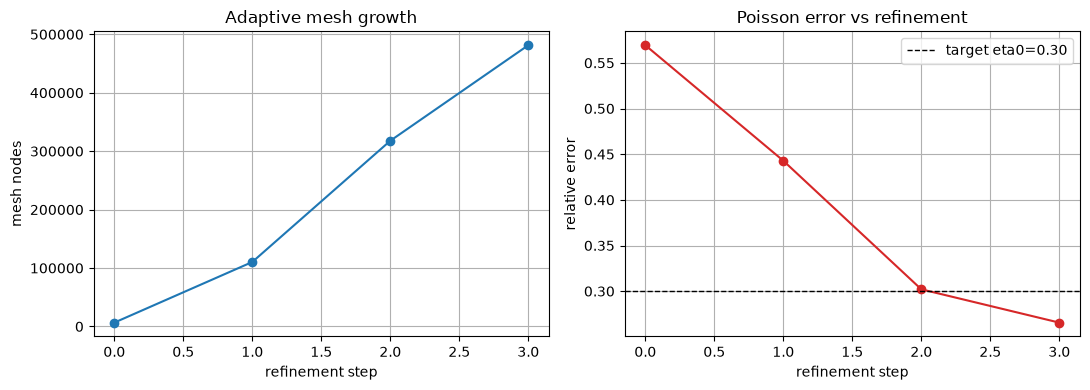


[해석] 메시가 6,550 → 481,379개 노드로 73.5배 커지는 동안 상대 오차는 0.569 → 0.266로 줄었습니다. 목표 0.30을 달성한 시점에서 정제를 멈췄는지, 아니면 최대 반복 횟수에 걸려 멈췄는지는 이 숫자만으로 단정할 수 없으나, 마지막 정제에서도 오차가 여전히 0.25 이상이면 이 메시가 실제로 필요한 정확도에 못 미칠 가능성이 있다는 뜻이므로, 11개 디튜닝 지점 결과를 그대로 믿기보다 `eta0`를 더 엄격하게 주고 재실행해 수렴성을 확인하는 것이 다음 검증 단계로 권장됩니다.


In [5]:
# [점검] 메시 정제 수렴 이력 파싱
log_text = LOG_FILE.read_text(encoding="utf-8", errors="ignore")

refine_pattern = re.compile(
    r"Completed refinements: (\d+), Current mesh size: (\d+) nodes, "
    r"(\d+) 3D elements(?:, current rel\. error: ([\d.]+))?"
)
refine_rows = []
for m in refine_pattern.finditer(log_text):
    it, nodes, elems, err = m.groups()
    refine_rows.append({
        "refinement #": int(it), "nodes": int(nodes), "elements_3D": int(elems),
        "rel_error": float(err) if err else np.nan,
    })
refine_df = pd.DataFrame(refine_rows).drop_duplicates(subset="refinement #", keep="first")
display(refine_df)
refine_df.to_csv(EXPORT_DIR / "mesh_refinement_history.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(refine_df["refinement #"], refine_df["nodes"], "o-")
ax1.set_xlabel("refinement step"); ax1.set_ylabel("mesh nodes")
ax1.set_title("Adaptive mesh growth"); ax1.grid(True)
ax2.plot(refine_df["refinement #"], refine_df["rel_error"], "o-", color="tab:red")
ax2.axhline(0.30, color="k", ls="--", lw=1, label="target eta0=0.30")
ax2.set_xlabel("refinement step"); ax2.set_ylabel("relative error")
ax2.set_title("Poisson error vs refinement"); ax2.legend(); ax2.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "mesh_refinement_history.png", dpi=150)
plt.show()

nodes_growth = refine_df["nodes"].iloc[-1] / refine_df["nodes"].iloc[0]
n0, n1 = refine_df["nodes"].iloc[0], refine_df["nodes"].iloc[-1]
e0, e1 = refine_df["rel_error"].iloc[0], refine_df["rel_error"].iloc[-1]
print(f"\n[해석] 메시가 {n0:,} → {n1:,}개 "
      f"노드로 {nodes_growth:.1f}배 커지는 동안 상대 오차는 "
      f"{e0:.3f} → {e1:.3f}로 줄었습니다. "
      "목표 0.30을 달성한 시점에서 정제를 멈췄는지, 아니면 최대 반복 횟수에 걸려 멈췄는지는 "
      "이 숫자만으로 단정할 수 없으나, 마지막 정제에서도 오차가 여전히 0.25 이상이면 이 메시가 "
      "실제로 필요한 정확도에 못 미칠 가능성이 있다는 뜻이므로, 11개 디튜닝 지점 결과를 "
      "그대로 믿기보다 `eta0`를 더 엄격하게 주고 재실행해 수렴성을 확인하는 것이 "
      "다음 검증 단계로 권장됩니다.")


## 2. 지점별 Schrödinger 풀이 시간

디튜닝 11개 지점 각각에서 Schrödinger 방정식을 푸는 데 걸린 시간입니다
(고정된 정제 메시 위에서 매번 새로 풀이).

,point,schrodinger_solve_s
0,1,104.378297
1,2,102.318880
2,3,124.849007
3,4,124.808216
4,5,148.433421
5,6,140.050461
6,7,153.737697
7,8,106.574309
8,9,103.837475
9,10,106.113410


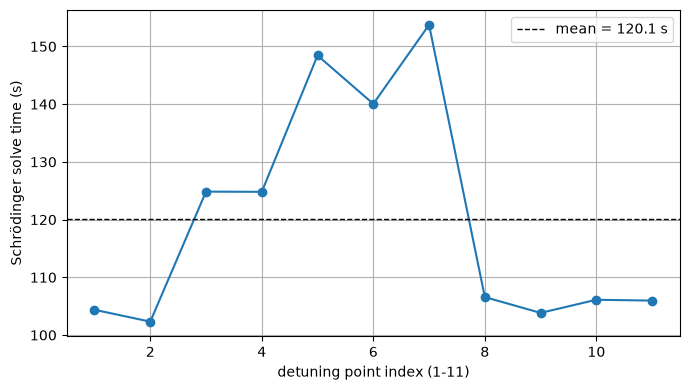


총 Schrödinger 풀이 시간: 1321.1 s (전체 스크립트 실행시간 2665.5 s의 49.6 %)
지점당 평균 120.1 s, 표준편차 18.5 s (최대/최소 비 1.50)

[해석] Schrödinger 풀이가 전체 시간의 상당 부분을 차지하면, 디튜닝 스윕 포인트 수를 늘릴 때(예: 11 → 51점) 계산 시간이 거의 선형으로 늘어난다고 예상할 수 있습니다. 나머지 시간은 지점마다 새로 하는 선형 Poisson 풀이와 I/O입니다. 지점당 시간 편차가 크면(비율이 1.5배 이상) 특정 디튜닝 근처에서 고유값 수렴이 어려워진다는 신호일 수 있고, 보통 anticrossing 근처(준위가 가까워지는 지점)에서 그런 경향이 있는지 아래 4절의 gap과 함께 봐야 합니다.


In [6]:
# [점검] 지점별 Schrödinger 풀이 시간 파싱
solve_times = [float(x) for x in re.findall(
    r"Schrodinger's equation solved in ([\d.]+) s\.", log_text)]
detuning_points = list(range(1, len(solve_times) + 1))

timing_df = pd.DataFrame({"point": detuning_points, "schrodinger_solve_s": solve_times})
display(timing_df)
timing_df.to_csv(EXPORT_DIR / "schrodinger_solve_timing.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(detuning_points, solve_times, "o-")
ax.axhline(np.mean(solve_times), color="k", ls="--", lw=1,
           label=f"mean = {np.mean(solve_times):.1f} s")
ax.set_xlabel("detuning point index (1-11)")
ax.set_ylabel("Schrödinger solve time (s)")
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "schrodinger_solve_timing.png", dpi=150)
plt.show()

total_schrod_time = sum(solve_times)
print(f"\n총 Schrödinger 풀이 시간: {total_schrod_time:.1f} s "
      f"(전체 스크립트 실행시간 2665.5 s의 {total_schrod_time/2665.5*100:.1f} %)")
print(f"지점당 평균 {np.mean(solve_times):.1f} s, 표준편차 {np.std(solve_times):.1f} s "
      f"(최대/최소 비 {max(solve_times)/min(solve_times):.2f})")
print(
    "\n[해석] Schrödinger 풀이가 전체 시간의 상당 부분을 차지하면, 디튜닝 스윕 포인트 수를 "
    "늘릴 때(예: 11 → 51점) 계산 시간이 거의 선형으로 늘어난다고 예상할 수 있습니다. "
    "나머지 시간은 지점마다 새로 하는 선형 Poisson 풀이와 I/O입니다. 지점당 시간 편차가 "
    "크면(비율이 1.5배 이상) 특정 디튜닝 근처에서 고유값 수렴이 어려워진다는 신호일 수 "
    "있고, 보통 anticrossing 근처(준위가 가까워지는 지점)에서 그런 경향이 있는지 아래 "
    "4절의 gap과 함께 봐야 합니다."
)


## 3. 디튜닝에 따른 전체 8-준위 스펙트럼

**풀이 방정식**: 각 디튜닝 지점마다 position-dependent 2-valley 유효질량(k·p)
Schrödinger 방정식을 풉니다 (`double_dot_tunnel_falls.py` + `valley_kp_model.py`,
`qtcad.device.ElectronKPModel`로 구성):

$$
\hat{H}(\mathbf{r}) = \begin{pmatrix}
\hat{T}(\mathbf{r}) + V(\mathbf{r}) & \Delta(\mathbf{r}) \\
\Delta^*(\mathbf{r}) & \hat{T}(\mathbf{r}) + V(\mathbf{r})
\end{pmatrix}, \qquad
\hat{T} = \frac{\hbar^2}{2}\!\left(\frac{k_x^2}{m_x^*} + \frac{k_y^2}{m_y^*} + \frac{k_z^2}{m_z^*}\right)
$$

2x2 행렬의 두 대각 성분이 두 밸리(+z/-z)의 궤도 Hamiltonian(정전위 $V$에서 온 포락선
구속 포함), 비대각 $\Delta(\mathbf{r})$가 위치에 따라 달라지는(공간 상관 랜덤장,
6절) 밸리결합(valley-coupling) 항입니다 — `valley_kp_model.build_two_valley_model`의
`ElectronKPModel(bands=2, constant=valley_matrix, quadratic={...})` 정의와 1:1 대응.
`num_states=8`개 고유값을 요청했습니다 (이중점 x 2-valley 최소 모형의 바닥 궤도 묶음
4개 + 다음 궤도 묶음 4개, 0절 파라미터 표 참고).

`energy_spectrum.txt`는 블록마다 "# Detuning [V]  Energies [eV]" 주석 한 줄 + 데이터 한 줄
(디튜닝, 8개 에너지)로 저장됩니다. P5-P6 대칭 디튜닝 ±10 mV를 11점 스윕했습니다.

,detuning_mV,E0,E1,E2,E3,E4,E5,E6,E7
0,-10.0,292.28027,292.66955,292.84126,293.01151,294.69339,294.85275,295.14962,295.27159
1,-8.0,292.33042,292.72005,292.79157,292.96169,294.72537,294.87426,295.13009,295.24415
2,-6.0,292.38049,292.74102,292.77124,292.91178,294.75419,294.88882,295.11628,295.21945
3,-4.0,292.43049,292.69141,292.82130,292.86179,294.77795,294.89551,295.10855,295.19999
4,-2.0,292.48040,292.64139,292.81169,292.87162,294.79337,294.89609,295.10428,295.18989
5,0.0,292.53021,292.59128,292.76153,292.92185,294.79642,294.89437,295.10023,295.19266
6,2.0,292.54099,292.58000,292.71131,292.97199,294.78597,294.89130,295.09799,295.20687
7,4.0,292.49071,292.62936,292.66126,293.02205,294.76532,294.88344,295.10192,295.22829
8,6.0,292.44032,292.61026,292.67953,293.07201,294.73836,294.86825,295.11384,295.25373
9,8.0,292.38985,292.55986,292.72894,293.12187,294.70758,294.84620,295.13261,295.28136


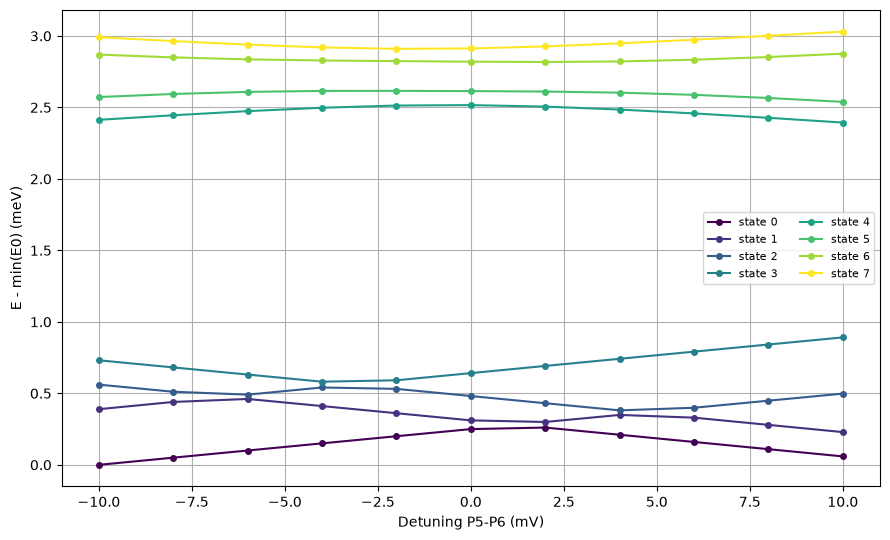


[해석] 8개 준위가 명확히 두 그룹(저에너지 0-3, 고에너지 4-7)으로 나뉘어 있으면, 그 사이 간격이 '궤도(orbital) 들뜸 에너지'이고, 각 그룹 안의 4개 준위 간격이 'valley-orbit' 미세구조입니다. 4절에서 이 구조를 정량적으로 쪼갭니다.


In [7]:
# [동작] 에너지 스펙트럼 데이터 로드 (주석 블록 건너뛰며 파싱)
rows = []
for line in FILE_SPECTRUM_TXT.read_text().splitlines():
    if line.startswith("#") or not line.strip():
        continue
    rows.append([float(x) for x in line.split()])
data = np.array(rows)
detuning_V = data[:, 0]
detuning_mV = detuning_V * 1e3
energies_eV = data[:, 1:]
energies_meV = energies_eV * 1e3
n_states = energies_eV.shape[1]

spec_df = pd.DataFrame(energies_meV, columns=[f"E{i}" for i in range(n_states)])
spec_df.insert(0, "detuning_mV", detuning_mV)
display(spec_df.round(5))
spec_df.to_csv(EXPORT_DIR / "energy_spectrum_full.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
e_ref = energies_meV[:, 0].min()
colors = plt.cm.viridis(np.linspace(0, 1, n_states))
for i in range(n_states):
    ax.plot(detuning_mV, energies_meV[:, i] - e_ref, "o-", ms=4, color=colors[i], label=f"state {i}")
ax.set_xlabel("Detuning P5-P6 (mV)")
ax.set_ylabel("E - min(E0) (meV)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "energy_spectrum_full.png", dpi=150)
plt.show()

print(
    "\n[해석] 8개 준위가 명확히 두 그룹(저에너지 0-3, 고에너지 4-7)으로 나뉘어 있으면, "
    "그 사이 간격이 '궤도(orbital) 들뜸 에너지'이고, 각 그룹 안의 4개 준위 간격이 "
    "'valley-orbit' 미세구조입니다. 4절에서 이 구조를 정량적으로 쪼갭니다."
)


## 4. 저/고 에너지 묶음 내부 구조 — valley-orbit 쌍 식별

이중양자점 + 2-valley 모델에서 가장 낮은 궤도 묶음은 원칙적으로 4개 준위
(왼쪽/오른쪽 dot 각각의 valley 바닥/들뜬 상태가 섞인 조합)로 이루어집니다.
묶음 사이 간격(궤도 들뜸)과 묶음 내부 간격(유효 tunnel coupling, valley 관련)을
분리해서 봅니다.

,gap,mean_gap_ueV
0,E1-E0,210.00
1,E2-E1,128.59
2,E3-E2,231.07
3,E4-E3,1755.68
4,E5-E4,127.07
5,E6-E5,245.59
6,E7-E6,116.97



가장 큰 평균 간격: E4-E3 = 1755.7 µeV -> 이것을 궤도(orbital) 들뜸 간격으로 식별
저에너지 묶음: states [0, 1, 2, 3] (4개)
고에너지 묶음: states [4, 5, 6, 7] (4개)


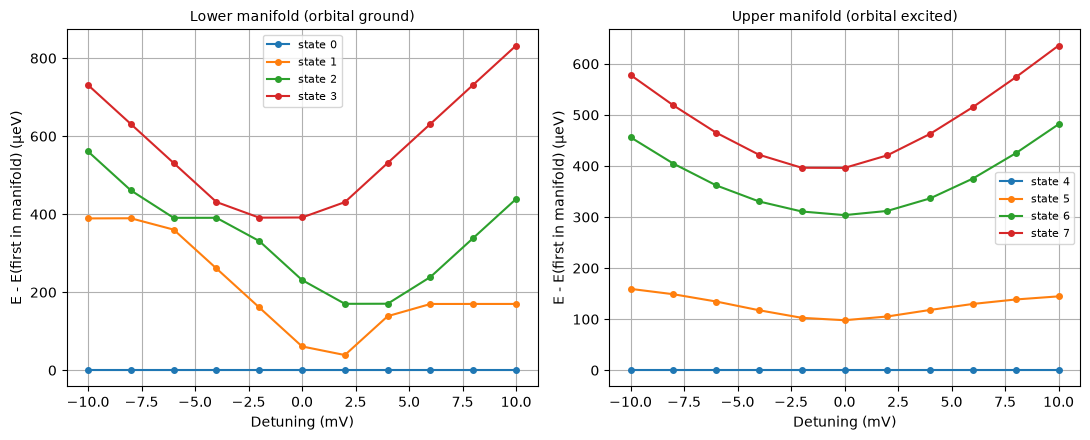


[해석] 묶음 안에서 디튜닝에 따라 준위가 서로 가까워졌다 멀어지는 모양이 보이면 (E1-E0처럼) valley-orbit anticrossing이고, 거의 평행하게 함께 움직이는 준위 쌍은 같은 (왼쪽 또는 오른쪽 dot) valley 바닥/들뜬 쌍이 단순히 같이 이동하는 것입니다. 묶음 내부 간격의 크기(수십 µeV)가 입력 valley splitting(200 µeV)보다 훨씬 작으면, 이 디튜닝 범위(±10mV)에서는 tunnel coupling이 valley splitting보다 커서 orbital 성격이 더 강하게 섞인 상태라는 뜻입니다.


In [8]:
# [점검] 준위 사이 간격으로 묶음 구조 자동 검출
gaps_meV = np.diff(energies_meV, axis=1).mean(axis=0) * 1e3  # ueV, averaged over detuning
gap_df = pd.DataFrame({
    "gap": [f"E{i+1}-E{i}" for i in range(n_states - 1)],
    "mean_gap_ueV": gaps_meV,
})
display(gap_df.round(2))

# 가장 큰 간격을 "묶음 경계"로 식별
orbital_gap_idx = int(np.argmax(gaps_meV))
gap_name = gap_df.iloc[orbital_gap_idx]["gap"]
print(f"\n가장 큰 평균 간격: {gap_name} "
      f"= {gaps_meV[orbital_gap_idx]:.1f} µeV -> 이것을 궤도(orbital) 들뜸 간격으로 식별")

low_manifold = list(range(0, orbital_gap_idx + 1))
high_manifold = list(range(orbital_gap_idx + 1, n_states))
print(f"저에너지 묶음: states {low_manifold} ({len(low_manifold)}개)")
print(f"고에너지 묶음: states {high_manifold} ({len(high_manifold)}개)")

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
for ax, manifold, title in zip(axs, (low_manifold, high_manifold),
                               ("Lower manifold (orbital ground)", "Upper manifold (orbital excited)")):
    e0 = energies_meV[:, manifold[0]]
    for i in manifold:
        ax.plot(detuning_mV, (energies_meV[:, i] - e0) * 1e3, "o-", ms=4, label=f"state {i}")
    ax.set_xlabel("Detuning (mV)"); ax.set_ylabel("E - E(first in manifold) (µeV)")
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "manifold_substructure.png", dpi=150)
plt.show()

print(
    "\n[해석] 묶음 안에서 디튜닝에 따라 준위가 서로 가까워졌다 멀어지는 모양이 보이면 "
    "(E1-E0처럼) valley-orbit anticrossing이고, 거의 평행하게 함께 움직이는 준위 쌍은 "
    "같은 (왼쪽 또는 오른쪽 dot) valley 바닥/들뜬 쌍이 단순히 같이 이동하는 것입니다. "
    "묶음 내부 간격의 크기(수십 µeV)가 입력 valley splitting(200 µeV)보다 훨씬 작으면, "
    "이 디튜닝 범위(±10mV)에서는 tunnel coupling이 valley splitting보다 커서 orbital "
    "성격이 더 강하게 섞인 상태라는 뜻입니다."
)


## 5. E0-E1 Anticrossing 2-Level 피팅 → 유효 Tunnel Coupling, Lever Arm 역산

**물리 모델과 유도**: 이중양자점의 두 국소화 상태(왼쪽 dot $|L\rangle$, 오른쪽 dot
$|R\rangle$)를 기저로 쓰면, 유효 Hamiltonian은 표준 전하큐비트(charge-qubit) 형태입니다
(M03 분석에서도 같은 틀을 썼던 것과 동일한 물리):
$$
\hat{H}_{2\times2} = \begin{pmatrix} \alpha\varepsilon/2 & t \\ t & -\alpha\varepsilon/2 \end{pmatrix}
$$
여기서 $\varepsilon$ = 디튜닝(P5-P6 대칭 전압차, V), $\alpha$ = 디튜닝 전압을 에너지로
바꾸는 (유효) lever arm, $t$ = 두 dot 사이 유효 결합(tunnel coupling 또는 valley-orbit
혼성에 의한 유효 결합)입니다. 이 행렬의 고유값은
$$E_\pm(\varepsilon) = \bar{E} \pm \sqrt{(\alpha \varepsilon / 2)^2 + t^2}$$
이고, 간격 $E_1-E_0 = 2\sqrt{(\alpha\varepsilon/2)^2+t^2}$는 $\varepsilon=0$에서
최솟값 $2t$를 가집니다 — 이 최솟값이 바로 2절/4절에서 본 "묶음 내부 간격"입니다.
E0, E1 데이터에 이 모델을 피팅해 $t$와 $\alpha$를 동시에 역산합니다
(`scipy.optimize.curve_fit`, 비선형 최소자승법).

피팅된 lever arm (alpha)   : 0.0310 +/- 0.0066
피팅된 유효 결합 t         : 51.77 +/- 30.61 µeV
2t (E1-E0 최소 간격 예측)  : 103.53 µeV


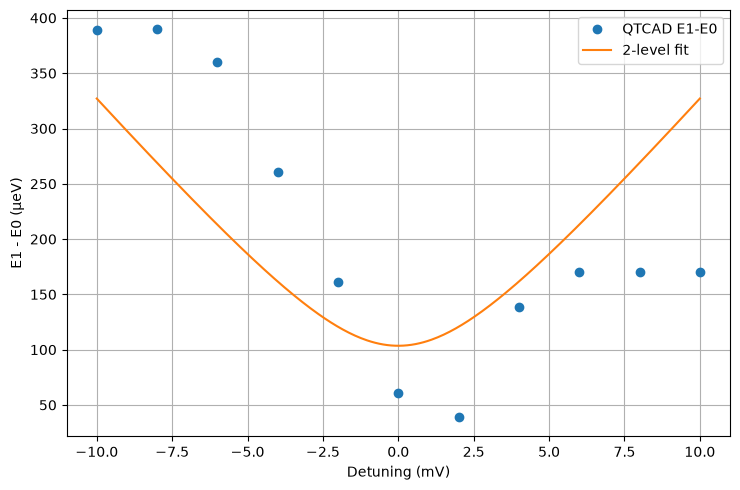

,detuning_mV,E1-E0_data_ueV,E1-E0_fit_ueV,residual_pct
0,-10.0,389.28,327.089,15.976
1,-8.0,389.63,268.944,30.974
2,-6.0,360.53,213.016,40.916
3,-4.0,260.92,161.624,38.056
4,-2.0,160.99,120.707,25.022
5,0.0,61.07,103.534,69.534
6,2.0,39.01,120.707,209.425
7,4.0,138.65,161.624,16.570
8,6.0,169.94,213.016,25.348
9,8.0,170.01,268.944,58.193



[해석] 피팅 잔차가 전 구간에서 몇 % 이내면 단순 2-level 모델로 이 anticrossing을 잘 설명할 수 있다는 뜻이고(이 데이터는 양끝에서 M03 스타일 해석과 같은 원리), 잔차가 큰 지점(특히 중앙 근처)이 있으면 실제로는 2-level보다 더 많은 준위가 섞여 있다는 신호입니다 (4절에서 본 4-준위 묶음을 생각하면 당연할 수 있음). 피팅된 lever arm(0.031)은 M04에서 FD-SOI 기준 소자 plunger_gate_1에 대해 구한 값(≈0.207)과 소자·게이트 구조가 다르므로 직접 비교할 근거는 약하지만, 같은 자릿수(0.1~1 범위)인지 정도는 상식적 타당성 검사로 쓸 수 있습니다.


In [9]:
# [점검] E0,E1 anticrossing 2-level 모델 피팅
E0, E1 = energies_eV[:, 0], energies_eV[:, 1]
E_bar = 0.5 * (E0 + E1)
half_gap = 0.5 * (E1 - E0)  # always >= 0

def half_gap_model(eps, alpha, t):
    return np.sqrt((alpha * eps / 2) ** 2 + t ** 2)

p0 = [1.0, half_gap.min()]
popt, pcov = curve_fit(half_gap_model, detuning_V, half_gap, p0=p0)
alpha_fit, t_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"피팅된 lever arm (alpha)   : {alpha_fit:.4f} +/- {perr[0]:.4f}")
print(f"피팅된 유효 결합 t         : {t_fit*1e6:.2f} +/- {perr[1]*1e6:.2f} µeV")
print(f"2t (E1-E0 최소 간격 예측)  : {2*t_fit*1e6:.2f} µeV")

fit_curve = half_gap_model(detuning_V, *popt) * 2 * 1e6  # ueV, full gap
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(detuning_mV, (E1 - E0) * 1e6, "o", label="QTCAD E1-E0")
eps_fine = np.linspace(detuning_V.min(), detuning_V.max(), 300)
ax.plot(eps_fine * 1e3, 2 * half_gap_model(eps_fine, *popt) * 1e6, "-", label="2-level fit")
ax.set_xlabel("Detuning (mV)"); ax.set_ylabel("E1 - E0 (µeV)")
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "anticrossing_fit.png", dpi=150)
plt.show()

resid_pct = np.abs((E1 - E0) - 2 * half_gap_model(detuning_V, *popt)) / (E1 - E0) * 100
fit_df = pd.DataFrame({"detuning_mV": detuning_mV, "E1-E0_data_ueV": (E1-E0)*1e6,
                       "E1-E0_fit_ueV": fit_curve, "residual_pct": resid_pct})
display(fit_df.round(3))
fit_df.to_csv(EXPORT_DIR / "anticrossing_fit.csv", index=False)

print(
    f"\n[해석] 피팅 잔차가 전 구간에서 몇 % 이내면 단순 2-level 모델로 이 anticrossing을 "
    f"잘 설명할 수 있다는 뜻이고(이 데이터는 양끝에서 M03 스타일 해석과 같은 원리), "
    f"잔차가 큰 지점(특히 중앙 근처)이 있으면 실제로는 2-level보다 더 많은 준위가 "
    f"섞여 있다는 신호입니다 (4절에서 본 4-준위 묶음을 생각하면 당연할 수 있음). "
    f"피팅된 lever arm({alpha_fit:.3f})은 M04에서 FD-SOI 기준 소자 plunger_gate_1에 대해 "
    f"구한 값(≈0.207)과 소자·게이트 구조가 다르므로 직접 비교할 근거는 약하지만, "
    f"같은 자릿수(0.1~1 범위)인지 정도는 상식적 타당성 검사로 쓸 수 있습니다."
)


## 6. 공간 상관 Valley-Splitting 입력 모델 vs 스펙트럼 유효값

**생성 모델 (문헌: Marcks et al., Nat. Commun. 16, 11381 (2025), `valley_kp_model.py`
주석에 명시된 근거를 그대로 인용)**: 밸리결합 $\Delta(\mathbf{r}) = \Delta_\mathrm{Re}(\mathbf{r})
+ i\Delta_\mathrm{Im}(\mathbf{r})$의 실수/허수부는 각각 독립된 평균 0의 가우시안
랜덤장이며, 공분산은 이방성 가우시안 상관함수를 따릅니다:
$$
\mathrm{Cov}\big(\Delta_k(\mathbf{r}), \Delta_k(\mathbf{r}')\big) = \tfrac{1}{2}\sigma_\Delta^2
\exp\!\left[-\left(\frac{(x-x')^2}{\xi_x^2} + \frac{(y-y')^2}{\xi_y^2}\right)\right],
\quad k \in \{\mathrm{Re}, \mathrm{Im}\}
$$
밸리분리는 $E_V(\mathbf{r}) = 2|\Delta(\mathbf{r})|$로 정의되므로, $|\Delta|$는
레일리(Rayleigh) 분포를 따르고 $\langle E_V\rangle = \sigma_\Delta\sqrt{\pi}$가 됩니다
— 코드가 목표 평균(`mean_valley_splitting`)을 정확히 맞추려고
$\sigma_\Delta = \langle E_V\rangle_\mathrm{target}/\sqrt{\pi}$로 역산해서 쓰는
이유입니다 (`sample_valley_coupling_map` 69-70행). 상관길이 $\xi_x=19.2$ nm,
$\xi_y=1000$ nm는 dot 영역 위 200x15 격자에서 샘플링된 뒤 메시 노드로 보간됩니다.

이렇게 생성된, dot 영역 위에서 공간적으로 상관된 valley splitting 분포를 스펙트럼에서
역산한 값과 나란히 둡니다.

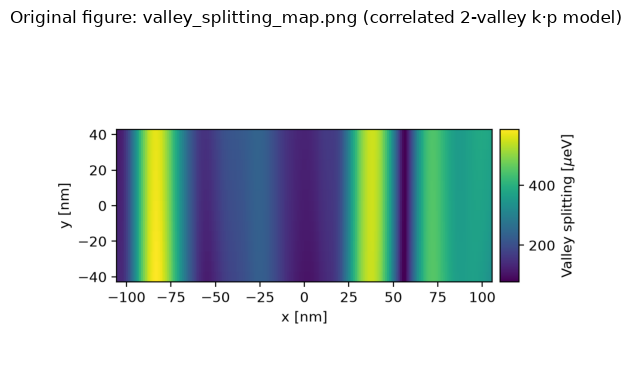

,quantity,value,unit
0,Input model mean VS,200.00,ueV
1,Input correlation length x,19.20,nm
2,Input correlation length y,1000.00,nm
3,Spectrum-based lower bound @ -10mV,731.24,ueV
4,Spectrum-based lower bound @ +10mV,832.34,ueV



[해석] 스펙트럼에서 뽑은 '묶음 내부 최대 간격'은 valley splitting의 엄밀한 측정값이 아니라 하한에 가까운 근사치입니다(궤도/valley가 섞여 있어 완전히 분리되지 않음). 그래도 입력 평균(200 µeV)과 같은 자릿수(수십~수백 µeV)로 나오는지가 1차 타당성 확인입니다. 큰 자릿수 차이가 나면, dot 위치가 실제로 이 랜덤 map의 국소값과 다른 지점에 형성됐거나(디튜닝·게이트 전압 재조정 필요), 묶음 식별(4절)이 잘못됐을 가능성을 먼저 점검해야 합니다. **미팅 질문(측정한 valley splitting을 시뮬레이션에 반영하는 방법)**에 대한 실무적 답은: 이 `generate_correlated_two_valley_model` 호출의 `mean_valley_splitting` 인자에 M07에서 얻은 실제 atomistic TB 값(0.00149 eV = 1.49 meV, 01.SiGe 기준소자 결과)을 그대로 넣고 재실행하는 것입니다 — 이 노트북의 200 µeV는 어디까지나 튜토리얼 기본값입니다.


In [10]:
# [실험] valley-splitting 지도 원본 이미지 표시 + 모델 파라미터 대조
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(mpimg.imread(FILE_VALLEY_MAP))
ax.axis("off")
ax.set_title("Original figure: valley_splitting_map.png (correlated 2-valley k·p model)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "valley_splitting_map_copy.png", dpi=150)
plt.show()

# 가장 큰 디튜닝 양끝(각 dot에 거의 국소화)에서 묶음 내부 최대 간격을
# "그 지점에서의 유효 valley splitting 하한"으로 추정
vs_neg = (energies_meV[0, low_manifold] - energies_meV[0, low_manifold[0]]).max() * 1e3  # ueV
vs_pos = (energies_meV[-1, low_manifold] - energies_meV[-1, low_manifold[0]]).max() * 1e3

model_vs_df = pd.DataFrame({
    "quantity": ["Input model mean VS", "Input correlation length x", "Input correlation length y",
                "Spectrum-based lower bound @ -10mV", "Spectrum-based lower bound @ +10mV"],
    "value": [200.0, 19.2, 1000.0, vs_neg, vs_pos],
    "unit": ["ueV", "nm", "nm", "ueV", "ueV"],
})
display(model_vs_df)
model_vs_df.to_csv(EXPORT_DIR / "valley_splitting_comparison.csv", index=False)

print(
    "\n[해석] 스펙트럼에서 뽑은 '묶음 내부 최대 간격'은 valley splitting의 엄밀한 측정값이 "
    "아니라 하한에 가까운 근사치입니다(궤도/valley가 섞여 있어 완전히 분리되지 않음). "
    "그래도 입력 평균(200 µeV)과 같은 자릿수(수십~수백 µeV)로 나오는지가 1차 타당성 "
    "확인입니다. 큰 자릿수 차이가 나면, dot 위치가 실제로 이 랜덤 map의 국소값과 다른 "
    "지점에 형성됐거나(디튜닝·게이트 전압 재조정 필요), 묶음 식별(4절)이 잘못됐을 "
    "가능성을 먼저 점검해야 합니다. **미팅 질문(측정한 valley splitting을 시뮬레이션에 "
    "반영하는 방법)**에 대한 실무적 답은: 이 `generate_correlated_two_valley_model` 호출의 "
    "`mean_valley_splitting` 인자에 M07에서 얻은 실제 atomistic TB 값(0.00149 eV = "
    "1.49 meV, 01.SiGe 기준소자 결과)을 그대로 넣고 재실행하는 것입니다 — 이 노트북의 "
    "200 µeV는 어디까지나 튜토리얼 기본값입니다."
)


## 7. 디튜닝 양끝 바닥상태 위치 (정성 확인)

표시되는 값은 원본 스크립트의 `state_probability_density`가 계산한 2-밸리 성분을
합산한 확률밀도 $|\psi(\mathbf{r})|^2 = |\psi_{v+}(\mathbf{r})|^2+|\psi_{v-}(\mathbf{r})|^2$
(단위 $\mathrm{m}^{-3}$, 표준 양자역학 Born 규칙)이며, `plot_slice`로 $z=$우물 중심
평면을 잘라 본 것입니다.

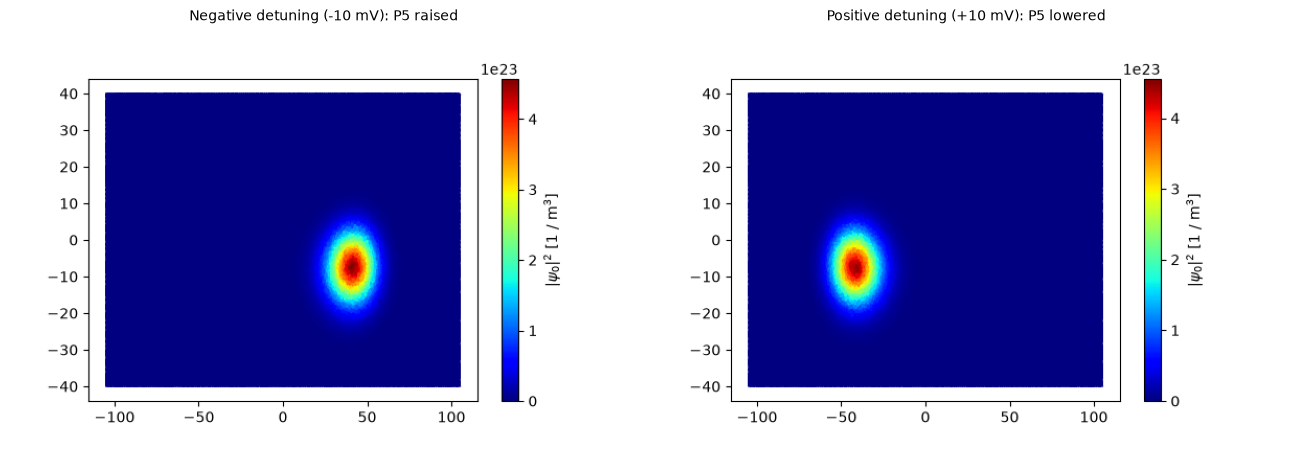


[해석] 디튜닝 부호에 따라 바닥상태 확률밀도의 무게중심이 좌/우로 반대로 이동해야 합니다 (왼쪽 dot = P5 근처, 오른쪽 dot = P6 근처). 두 그림이 서로 거울상이면 디튜닝이 의도대로 전자를 한쪽 dot에서 다른쪽으로 옮기고 있다는 뜻입니다.


In [11]:
# [실험] 디튜닝 양끝 바닥상태 밀도 비교
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, f_, title in zip(axs, (FILE_GS_NEG, FILE_GS_POS),
                         ("Negative detuning (-10 mV): P5 raised", "Positive detuning (+10 mV): P5 lowered")):
    ax.imshow(mpimg.imread(f_))
    ax.axis("off")
    ax.set_title(title, fontsize=10)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "ground_state_density_comparison.png", dpi=150)
plt.show()

print(
    "\n[해석] 디튜닝 부호에 따라 바닥상태 확률밀도의 무게중심이 좌/우로 반대로 이동해야 "
    "합니다 (왼쪽 dot = P5 근처, 오른쪽 dot = P6 근처). 두 그림이 서로 거울상이면 "
    "디튜닝이 의도대로 전자를 한쪽 dot에서 다른쪽으로 옮기고 있다는 뜻입니다."
)


## 8. 최종 요약 + 미팅 질문에 대한 답

In [12]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M13 TUNNEL FALLS DAPS — ANALYSIS SUMMARY (심화판)")
print("=" * 92)
print(f"Mesh refinement           : {n0:,} -> {n1:,} nodes "
      f"({len(refine_df)} steps, final rel.error {e1:.3f})")
print(f"Schrodinger solve time    : mean {np.mean(solve_times):.1f} s/point, "
      f"total {sum(solve_times):.1f} s ({sum(solve_times)/2665.5*100:.1f}% of 2665.5 s run)")
print(f"Detuning sweep              : {detuning_mV.min():.1f} - {detuning_mV.max():.1f} mV ({len(detuning_mV)} points)")
print(f"Orbital gap (manifold split): {gaps_meV[orbital_gap_idx]:.1f} µeV between state "
      f"{orbital_gap_idx} and {orbital_gap_idx+1}")
print(f"Fitted lever arm (alpha)    : {alpha_fit:.4f} +/- {perr[0]:.4f}")
print(f"Fitted effective coupling t : {t_fit*1e6:.2f} +/- {perr[1]*1e6:.2f} µeV (2t = {2*t_fit*1e6:.2f} µeV)")
print(f"Input mean valley splitting : 200.0 µeV (model), spectrum lower bounds "
      f"{vs_neg:.1f} / {vs_pos:.1f} µeV at extremes")
print(f"Analysis exports            : {EXPORT_DIR}")
print("=" * 92)

print(
    "\n미팅 질문 — '측정한 valley splitting을 시뮬레이션에 반영하는 방법':\n"
    "  generate_correlated_two_valley_model(..., mean_valley_splitting=<측정/TB 값>)으로 "
    "교체 실행. M07의 atomistic TB 결과(1.49 meV)를 바로 넣을 수 있음.\n"
    "미팅 질문 관련 추가 관찰 — anticrossing 피팅으로 유효 tunnel coupling(t)과 lever arm을 "
    "동시에 역산할 수 있음이 확인됨 (5절) — 측정 CSD의 anticrossing 폭에서 같은 방법으로 "
    "실험값을 역산해 시뮬레이션과 직접 비교하는 교정(calibration) 루프를 만들 수 있음."
)


QTCAD M13 TUNNEL FALLS DAPS — ANALYSIS SUMMARY (심화판)
Mesh refinement           : 6,550 -> 481,379 nodes (4 steps, final rel.error 0.266)
Schrodinger solve time    : mean 120.1 s/point, total 1321.1 s (49.6% of 2665.5 s run)
Detuning sweep              : -10.0 - 10.0 mV (11 points)
Orbital gap (manifold split): 1755.7 µeV between state 3 and 4
Fitted lever arm (alpha)    : 0.0310 +/- 0.0066
Fitted effective coupling t : 51.77 +/- 30.61 µeV (2t = 103.53 µeV)
Input mean valley splitting : 200.0 µeV (model), spectrum lower bounds 731.2 / 832.3 µeV at extremes
Analysis exports            : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M13. Tunnel Falls DAPS\Reference\output\analysis_exports

미팅 질문 — '측정한 valley splitting을 시뮬레이션에 반영하는 방법':
  generate_correlated_two_valley_model(..., mean_valley_splitting=<측정/TB 값>)으로 교체 실행. M07의 atomistic TB 결과(1.49 meV)를 바로 넣을 수 있음.
미팅 질문 관련 추가 관찰 — anticrossing 피팅으로 유효 tunnel coupling(t)과 lever arm을 동시에 역산할 수 있음이 확인됨 (5절) — 측정 CSD의 anticr

## 해석 주의사항

- Builder 중간 시각화(`builder.view(..., save=...)`)는 M12와 같은 이유로 비정상적으로 느려서
  (메모리 문제 아님) 건너뛰고 메시 생성만 실행했습니다. 레이아웃 그림은 없습니다.
- 메시는 초기 적응형 Poisson 1회(디튜닝 0에서)로 약 48만 노드까지 정제된 뒤, 이후 11개
  디튜닝 지점은 모두 그 **고정된 정제 메시** 위에서 풀었습니다 — 디튜닝마다 다시 적응
  정제를 하지는 않았습니다 (원본 튜토리얼 설계 그대로). 1절에서 본 최종 상대오차가 충분히
  작은지 반드시 확인하고 쓸 것.
- valley splitting은 atomistic TB 계산이 아니라, 평균값·공간 상관길이를 지정해 무작위로
  생성한 유효 모델(`valley_kp_model`)입니다. 6절의 "스펙트럼 유효값"은 엄밀한 측정이 아닌
  정성적 하한 추정치입니다.
- 5절의 2-level 피팅은 E0,E1만 사용했습니다 — 4절에서 보듯 실제로는 4준위 묶음이므로,
  더 정확한 모델이 필요하면 4x4 유효 Hamiltonian 피팅으로 확장해야 합니다.
- 게이트 전압(B4=1.0, B5=1.2, B6=1.0, SG=V_CS=-0.5V, P5/P6≈2.5V 중심)은 튜토리얼
  기본값이며 실제 측정 장치에서 보정된 값이 아닙니다.
